In [20]:
import sys
from pathlib import Path


import numpy as np
import cv2

from ultrasound_tracker.legacy.hough_detector import HoughDetector

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS
Chargé : 2667 frames à 33.3 fps
FPS: 33.341
Frame shape: (562, 706)


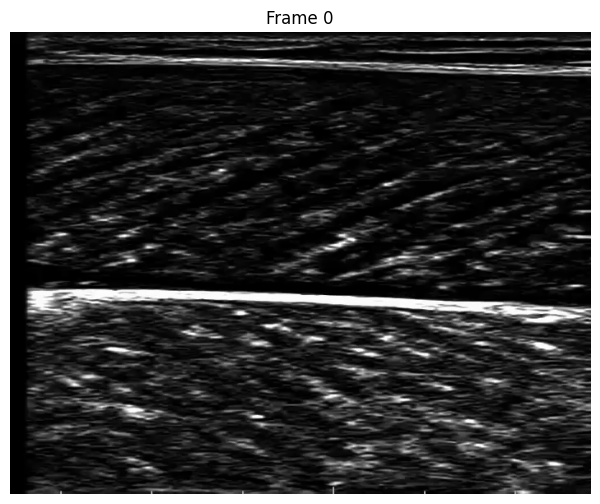

In [21]:
import matplotlib.pyplot as plt

current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

from ultrasound_tracker.legacy.preprocessing import load_video
from ultrasound_tracker.roi import (
    draw_rois,
    extract_roi,
    load_rois,
)

VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"

frames, fps = load_video(str(VIDEO_PATH))
frame0 = frames[0]

print("FPS:", fps)
print("Frame shape:", frame0.shape)

plt.figure(figsize=(10, 6))
plt.imshow(frame0, cmap="gray")
plt.title("Frame 0")
plt.axis("off")
plt.show()

{'superficial': (15, 21, 690, 42), 'deep': (16, 298, 689, 76), 'fascicle': (17, 65, 686, 226)}


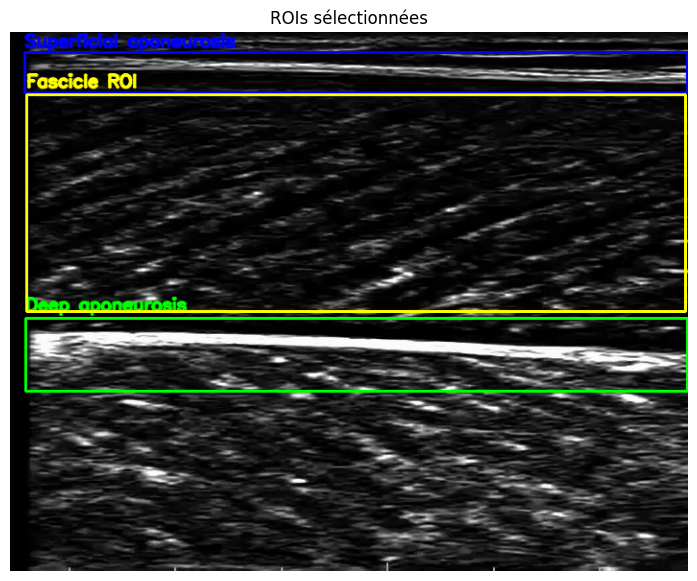

In [22]:
current = Path.cwd()

if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"

rois = load_rois(ROI_PATH)
print(rois)

vis = draw_rois(frame0, rois)

plt.figure(figsize=(12, 7))
plt.imshow(vis[..., ::-1])
plt.axis("off")
plt.title("ROIs sélectionnées")
plt.show()

In [23]:
def offset_lines_to_global(lines, roi):
    """
    Convert lines detected inside a ROI to full-image coordinates.

    lines: ndarray shape (N, 4), format [x1, y1, x2, y2]
    roi: (x, y, w, h)
    """
    if lines is None:
        return None

    x, y, w, h = roi
    lines_global = lines.copy().astype(np.float32)
    lines_global[:, [0, 2]] += x
    lines_global[:, [1, 3]] += y

    return lines_global

In [24]:
fascicle_roi = rois["fascicle"]
fascicle_img = extract_roi(frame0, fascicle_roi)

fascicle_detector = HoughDetector(
    angle_min=20,
    angle_max=50,
    canny_low=30,
    canny_high=90,
    hough_threshold=60,
    min_line_length=40,
    max_line_gap=8,
)

fas_lines_local, fas_angles, fas_lengths = fascicle_detector.detect(fascicle_img)
fas_lines_global = offset_lines_to_global(fas_lines_local, fascicle_roi)

print("Nombre de lignes fasciculaires :", None if fas_lines_global is None else len(fas_lines_global))

if fas_angles is not None and len(fas_angles) > 0:
    print("Angles détectés :", fas_angles)
    print("Angle médian :", np.median(fas_angles))

Nombre de lignes fasciculaires : 2
Angles détectés : [20.09523  20.556044]
Angle médian : 20.325638


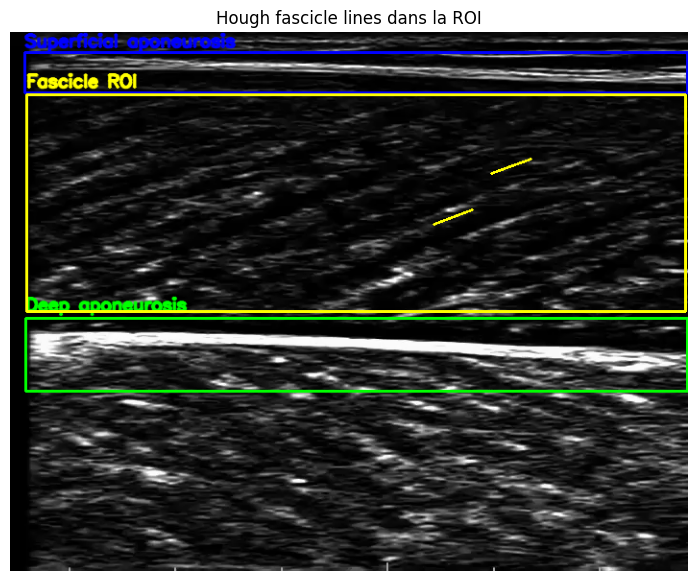

In [25]:
vis = draw_rois(frame0, rois)

if fas_lines_global is not None:
    for line in fas_lines_global:
        x1, y1, x2, y2 = line.astype(int)
        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 255), 2)

plt.figure(figsize=(12, 7))
plt.imshow(vis[..., ::-1])
plt.axis("off")
plt.title("Hough fascicle lines dans la ROI")
plt.show()

In [26]:
apo_detector = HoughDetector(
    angle_min=-15,
    angle_max=15,
    canny_low=30,
    canny_high=90,
    hough_threshold=50,
    min_line_length=80,
    max_line_gap=15,
)

sup_img = extract_roi(frame0, rois["superficial"])
deep_img = extract_roi(frame0, rois["deep"])

sup_lines_local, sup_angles, sup_lengths = apo_detector.detect(sup_img)
deep_lines_local, deep_angles, deep_lengths = apo_detector.detect(deep_img)

sup_lines_global = offset_lines_to_global(sup_lines_local, rois["superficial"])
deep_lines_global = offset_lines_to_global(deep_lines_local, rois["deep"])

print("Superficial lines :", None if sup_lines_global is None else len(sup_lines_global))
print("Deep lines :", None if deep_lines_global is None else len(deep_lines_global))

if sup_angles is not None and len(sup_angles) > 0:
    print("Angle sup médian :", np.median(sup_angles))

if deep_angles is not None and len(deep_angles) > 0:
    print("Angle deep médian :", np.median(deep_angles))

Superficial lines : 13
Deep lines : 31
Angle sup médian : -1.7899106
Angle deep médian : 0.0


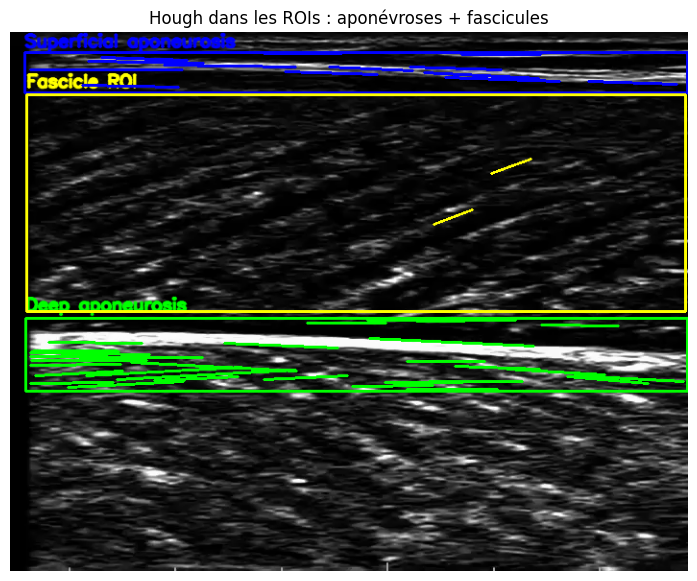

In [27]:
vis = draw_rois(frame0, rois)

if sup_lines_global is not None:
    for line in sup_lines_global:
        x1, y1, x2, y2 = line.astype(int)
        cv2.line(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)

if deep_lines_global is not None:
    for line in deep_lines_global:
        x1, y1, x2, y2 = line.astype(int)
        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

if fas_lines_global is not None:
    for line in fas_lines_global:
        x1, y1, x2, y2 = line.astype(int)
        cv2.line(vis, (x1, y1), (x2, y2), (0, 255, 255), 2)

plt.figure(figsize=(12, 7))
plt.imshow(vis[..., ::-1])
plt.axis("off")
plt.title("Hough dans les ROIs : aponévroses + fascicules")
plt.show()

#Je trouve que la visualisation des des deux aponeurosis est à chier, je vais aller coder la méthode Frangi pour au moins sortir un vecteur.